# Text Simplification Metrics Analysis
This notebook analyzes text simplification results produced by different tools and models, using SARI, BLEU, BERTScore, and Readability Indices (Fernández-Huerta, INFLESZ, and Mu).

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.metrics.process_data import SummaryColumn 
from src.metrics.mer_trans_metrics.calculator import MerTrans
from src.utils import clean_text

In [84]:
# Configuración de estilos para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar los datos
df = pd.read_excel('metrics.xlsx', sheet_name='Summary by Document')

# Limpiar los datos: quitar PROMEDIO
df = df[df['document_id'] != 'PROMEDIO'].copy()

# Definir los tres grupos de análisis
grupo1_tools = [
    'Placea',
    'Asistente de lectura fácil “Antonio Gonzales Crespo”',
    'Asistente de lectura fácil “Mark Jonathan Camacho Escatel”: ',
    'Asistente Lectura Facilitada "Francisco Javier Alvarez Jimenez"',
]
grupo2_tools = ['Gemini 3.1 Pro', 'GPT 5.4 Think', 'Claude Sonnet 4.6', 'deepseek-v3.2']
grupo3_tools = ['FACILE', 'SimpleText (ClearText)', 'Modelo_Qwen3.5_9B']

def asignar_grupo(doc_id):
    if doc_id in grupo1_tools: return 'Group 1: Conversational Agents'
    if doc_id in grupo2_tools: return 'Group 2: Foundation Models'
    if doc_id in grupo3_tools: return 'Group 3: UNE Standard'
    return 'Other'

df['Grupo'] = df['document_id'].apply(asignar_grupo)
ORDER_BY = [SummaryColumn.ORIG_SARI, "Compliance"]

# Seleccionar las métricas clave para el análisis
metricas = [
    SummaryColumn.ORIG_BLEU,
    SummaryColumn.GOLD_BLEU,
    SummaryColumn.ORIG_SARI,
    SummaryColumn.ORIG_BERTSCORE_F1,
    SummaryColumn.GOLD_BERTSCORE_F1,
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.GOLD_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING,
    SummaryColumn.GOLD_ROBERTA_SENSE_FACIL_PRESERVES_MEANING,
    "Compliance"
    ]

print("Data loaded. Total tools to analyze:", len(df))


Data loaded. Total tools to analyze: 11


In [85]:
DATA_TOTAL_CHECKER = "totales_checkers.xlsx"
df_total_checker = pd.read_excel(DATA_TOTAL_CHECKER)
df_total_checker.rename(columns={"Unnamed: 0": "Tool"}, inplace=True)
df_total_checker

,Tool,Items Fulfilled,Compliance
0,Lectura Fácil [Referencia],15.0,100.000
1,"Asistente Lectura Facilitada ""Francisco Javier...",15.0,100.000
2,Asistente de lectura fácil “Antonio Gonzales C...,14.5,96.667
3,FACILE,14.0,93.333
4,Modelo_Qwen3.5_9B,14.0,93.333
5,Placea,13.5,90.000
6,Asistente de lectura fácil “Mark Jonathan Cama...,13.5,90.000
7,GPT 5.4 Think,12.5,83.333
8,SimpleText (ClearText),12.5,83.333
9,deepseek-v3.2,12.0,80.000


In [86]:
# Join checker totals with main dataframe
df = df.merge(df_total_checker, left_on='document_id', right_on='Tool', how='left')
df.drop(columns=['Tool'], inplace=True)
df[["document_id", "Items Fulfilled", "Compliance"]]

,document_id,Items Fulfilled,Compliance
0,"Asistente Lectura Facilitada ""Francisco Javier...",15.0,100.000
1,Asistente de lectura fácil “Antonio Gonzales C...,14.5,96.667
2,Asistente de lectura fácil “Mark Jonathan Cama...,13.5,90.000
3,Claude Sonnet 4.6,11.0,73.333
4,FACILE,14.0,93.333
5,GPT 5.4 Think,12.5,83.333
6,Gemini 3.1 Pro,11.5,76.667
7,Modelo_Qwen3.5_9B,14.0,93.333
8,Placea,13.5,90.000
9,SimpleText (ClearText),12.5,83.333


## 1. Group 1: Pre-parameterized Conversational Agents (Encapsulated Assistants)
Comparison between pre-parameterized conversational agents: Placea and the three custom ChatGPT assistants.

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Compliance
0,"Asistente Lectura Facilitada ""Francisco Javier...",0.1512,0.1809,50.6440,0.7518,0.7667,86.8476,85.9946,0.9900,0.9898,100.000
2,Asistente de lectura fácil “Mark Jonathan Cama...,0.0653,0.0921,47.2610,0.7203,0.7492,88.8728,92.0436,0.9900,0.9903,90.000
1,Asistente de lectura fácil “Antonio Gonzales C...,0.0594,0.0716,46.7219,0.7464,0.7321,86.0144,88.2561,0.9911,0.9918,96.667
8,Placea,0.0867,0.0789,42.1956,0.7563,0.7424,87.9767,90.3143,0.9892,0.9892,90.000


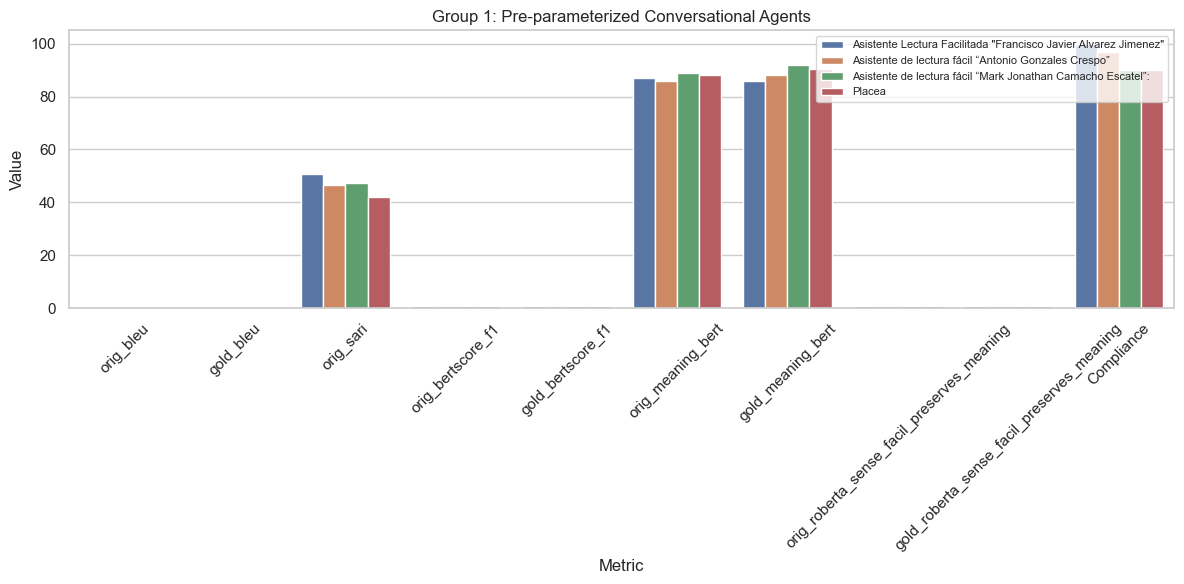

Best agent in Group 1: Asistente Lectura Facilitada "Francisco Javier Alvarez Jimenez"


In [87]:
df_g1 = df[df['document_id'].isin(grupo1_tools)].copy()
display(df_g1[['document_id'] + metricas].sort_values(by=ORDER_BY, ascending=False))

df_g1_melt = df_g1.melt(id_vars='document_id', value_vars=metricas, var_name='Metric', value_name='Value')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_g1_melt, x='Metric', y='Value', hue='document_id')
plt.title('Group 1: Pre-parameterized Conversational Agents')
plt.xticks(rotation=45)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

mejor_g1_id = df_g1.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print('Best agent in Group 1:', mejor_g1_id)

## 2. Group 2: General-Purpose Foundation Models (Direct Interaction)
Comparison between general-purpose language models applied without specific parameterization.

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Compliance
10,deepseek-v3.2,0.1627,0.1857,53.3765,0.7612,0.7856,84.5235,91.0221,0.9895,0.9901,80.000
3,Claude Sonnet 4.6,0.1707,0.1566,50.2891,0.7891,0.7723,82.4910,78.5779,0.9755,0.9724,73.333
5,GPT 5.4 Think,0.1754,0.1673,50.1571,0.8051,0.7702,94.0719,93.8518,0.9875,0.9847,83.333
6,Gemini 3.1 Pro,0.0625,0.1324,49.3049,0.6841,0.7627,79.6245,89.8177,0.9874,0.9897,76.667


C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_6644\3073099754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_g2, x='document_id', y=SummaryColumn.ORIG_SARI, palette='viridis')


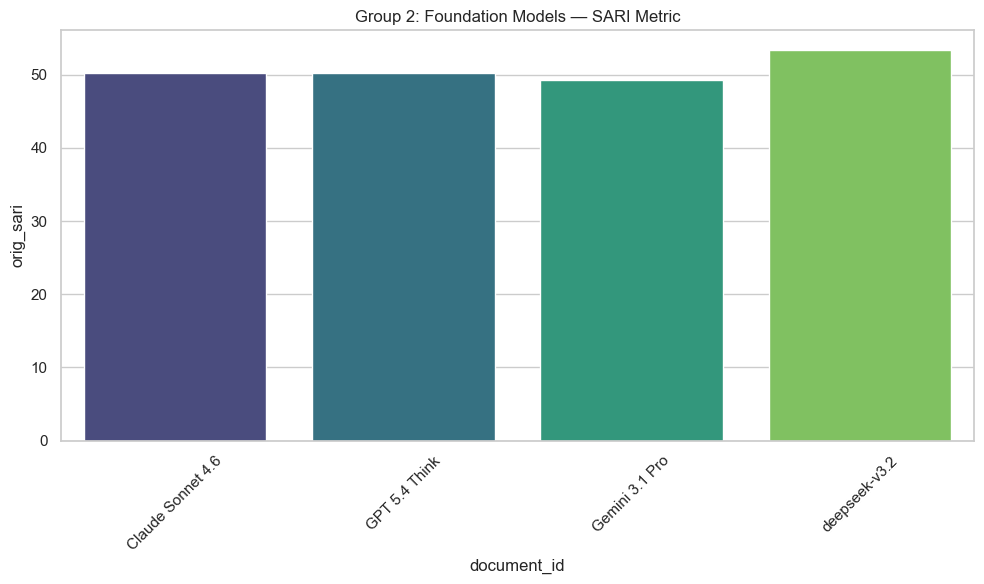

Best model in Group 2: deepseek-v3.2


In [88]:
df_g2 = df[df['document_id'].isin(grupo2_tools)].copy()
display(df_g2[['document_id'] + metricas].sort_values(by=ORDER_BY, ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=df_g2, x='document_id', y=SummaryColumn.ORIG_SARI, palette='viridis')
plt.title('Group 2: Foundation Models — SARI Metric')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

mejor_g2_id = df_g2.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print('Best model in Group 2:', mejor_g2_id)

## 3. Group 3: Normative and Standardized Approach (UNE Standard)
Comparison between FACILE, SimpleText (ClearText), and Modelo_Qwen3.5_9B — tools based on UNE standards or trained on simplification corpora.

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Compliance
7,Modelo_Qwen3.5_9B,0.1341,0.0814,44.6969,0.7516,0.7441,90.3709,87.8921,0.9897,0.9877,93.333
9,SimpleText (ClearText),0.8188,0.1701,41.0793,0.9496,0.7208,94.5266,87.5685,0.9798,0.9699,83.333
4,FACILE,0.7276,0.1619,39.6624,0.9247,0.7262,94.5268,90.8270,0.9648,0.9526,93.333


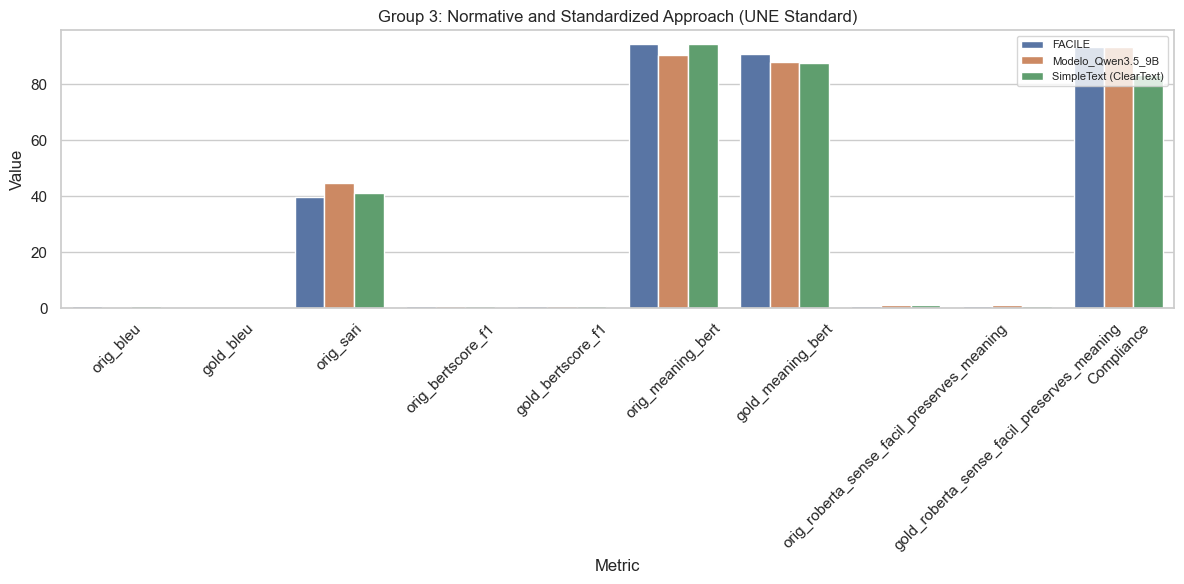

Best model in Group 3: Modelo_Qwen3.5_9B


In [89]:
df_g3 = df[df['document_id'].isin(grupo3_tools)].copy()
display(df_g3[['document_id'] + metricas].sort_values(by=ORDER_BY, ascending=False))

df_g3_melt = df_g3.melt(id_vars='document_id', value_vars=metricas, var_name='Metric', value_name='Value')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_g3_melt, x='Metric', y='Value', hue='document_id')
plt.title('Group 3: Normative and Standardized Approach (UNE Standard)')
plt.xticks(rotation=45)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

mejor_g3_id = df_g3.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print('Best model in Group 3:', mejor_g3_id)

## 4. Comparison of Best Models per Group
Comparing the winner of each group to identify the best overall approach.

,document_id,Grupo,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Compliance
10,deepseek-v3.2,Group 2: Foundation Models,0.1627,0.1857,53.3765,0.7612,0.7856,84.5235,91.0221,0.9895,0.9901,80.000
0,"Asistente Lectura Facilitada ""Francisco Javier...",Group 1: Conversational Agents,0.1512,0.1809,50.6440,0.7518,0.7667,86.8476,85.9946,0.9900,0.9898,100.000
7,Modelo_Qwen3.5_9B,Group 3: UNE Standard,0.1341,0.0814,44.6969,0.7516,0.7441,90.3709,87.8921,0.9897,0.9877,93.333


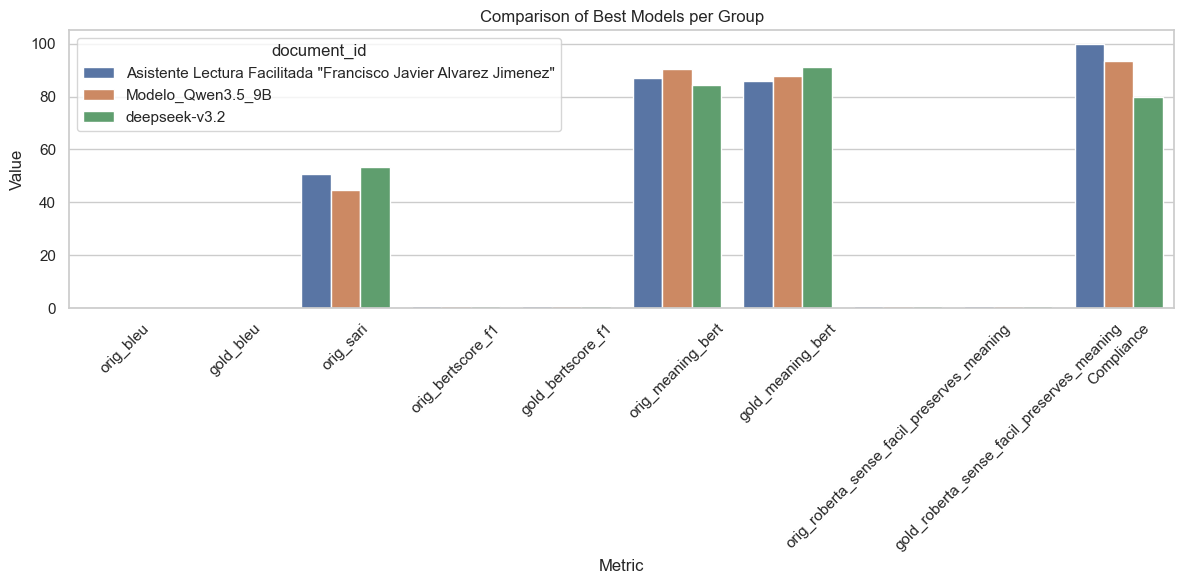

Best overall model: deepseek-v3.2


In [90]:
mejores_modelos_ids = [mejor_g1_id, mejor_g2_id, mejor_g3_id]
df_mejores_modelos = df[df['document_id'].isin(mejores_modelos_ids)].copy()
display(df_mejores_modelos[['document_id', 'Grupo'] + metricas].sort_values(by=ORDER_BY, ascending=False))

df_mejores_melt = df_mejores_modelos.melt(id_vars=['document_id', 'Grupo'], value_vars=metricas, var_name='Metric', value_name='Value')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_mejores_melt, x='Metric', y='Value', hue='document_id')
plt.title('Comparison of Best Models per Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

el_mejor_modelo_id = df_mejores_modelos.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print('Best overall model:', el_mejor_modelo_id)

## 5. Global Comparison: All Tools by Group
Overview of performance across all tools, grouped by category, on the 4 main metrics.

C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_6644\2797538981.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha='right', fontsize=7)
C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_6644\2797538981.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha='right', fontsize=7)
C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_6644\2797538981.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha='right', fontsize=7)
C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_6644\2797538981.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of

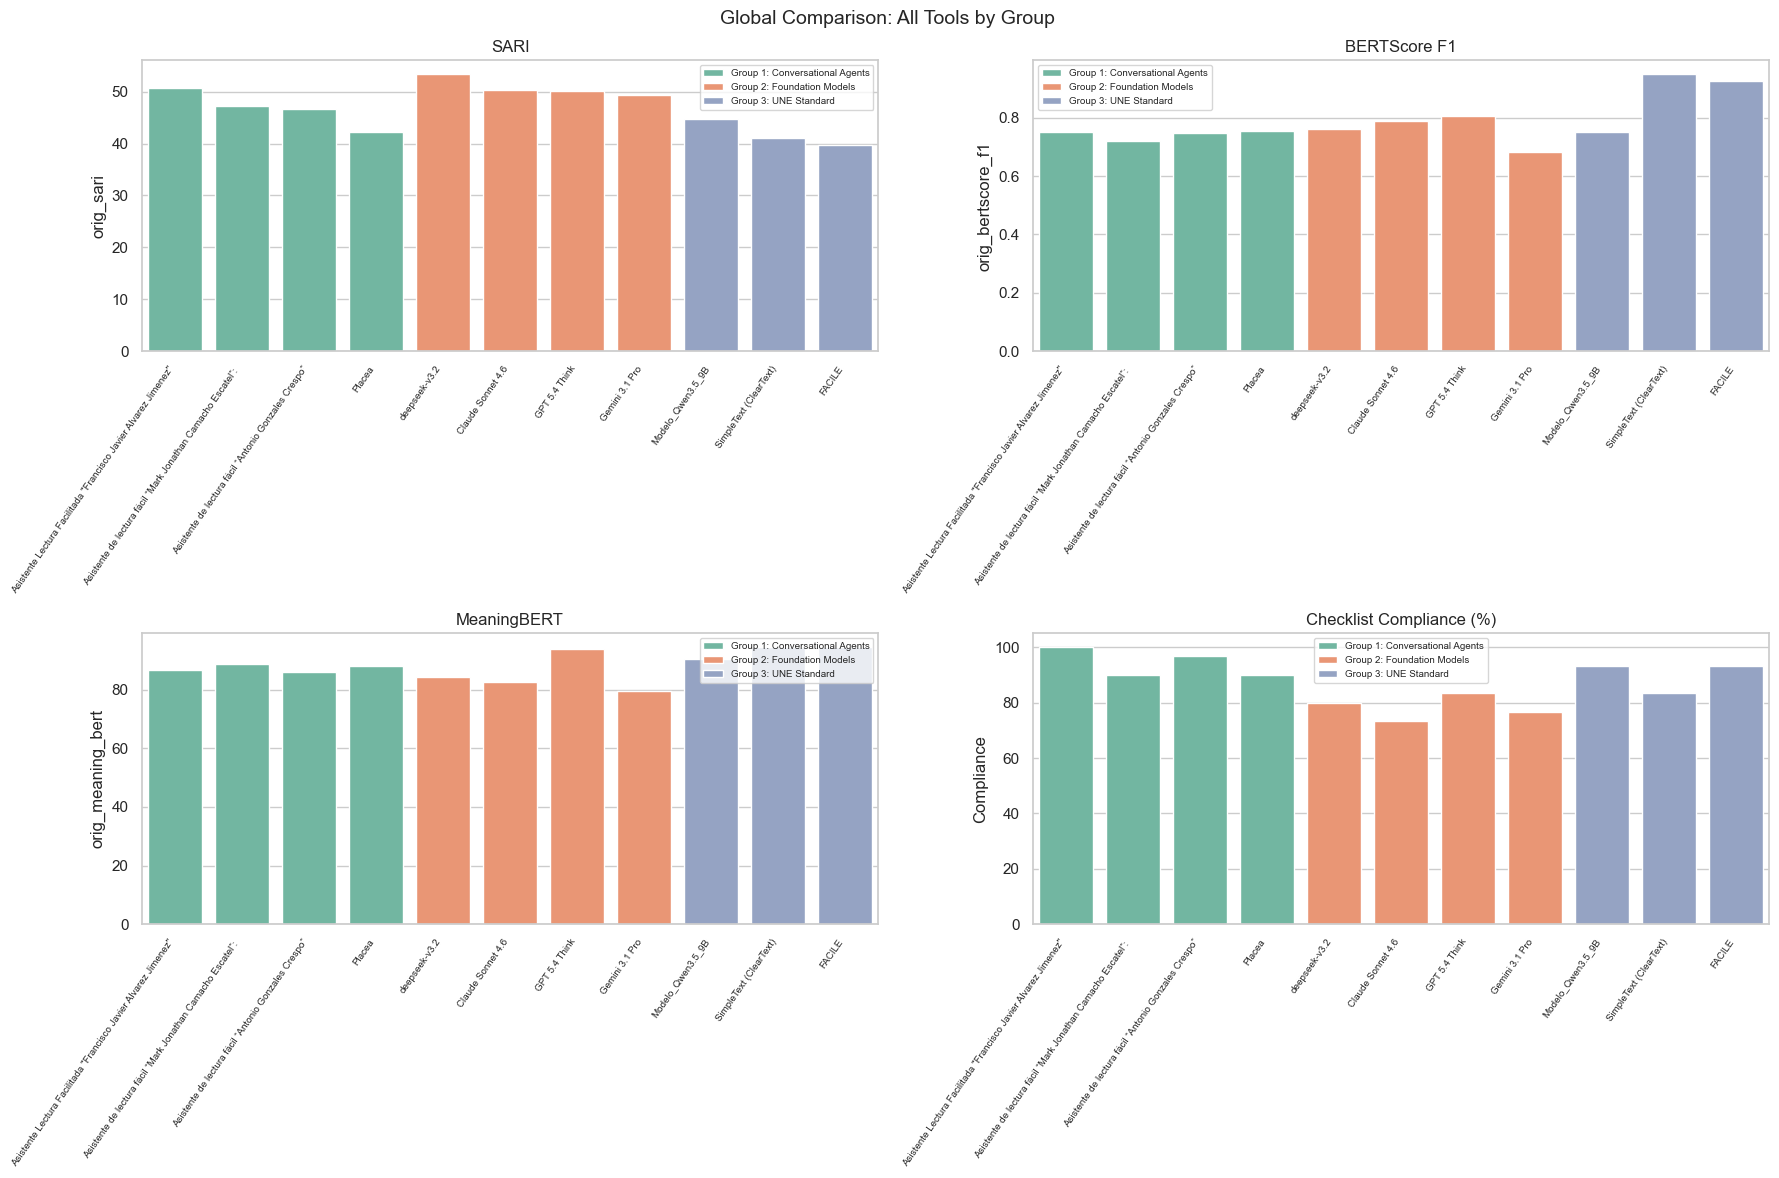

In [91]:
df_sorted = df.sort_values(by=['Grupo', SummaryColumn.ORIG_SARI], ascending=[True, False])
metricas_plot = [SummaryColumn.ORIG_SARI, SummaryColumn.ORIG_BERTSCORE_F1,
                 SummaryColumn.ORIG_MEANING_BERT, 'Compliance']
titles_plot = ['SARI', 'BERTScore F1', 'MeaningBERT', 'Checklist Compliance (%)']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, metrica, title in zip(axes.flat, metricas_plot, titles_plot):
    sns.barplot(data=df_sorted, x='document_id', y=metrica, hue='Grupo',
                palette='Set2', dodge=False, ax=ax)
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha='right', fontsize=7)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

plt.suptitle('Global Comparison: All Tools by Group', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Stability Analysis and Relationship with SARI
In this section we analyze how "stable" each tool is. Stability is defined as consistency in performance across all metrics.
To achieve this:
1. We normalize all metrics (0–1 scale).
2. We compute the standard deviation of these normalized metrics for each tool. A lower deviation indicates greater stability (balance between simplification quality, semantic preservation, and readability).

Tools ranked by Stability (Lower Std Dev = More Stable)


,document_id,orig_sari,stability_std,norm_mean
5,GPT 5.4 Think,50.1571,0.277992,0.700129
3,Claude Sonnet 4.6,50.2891,0.307980,0.396093
7,Modelo_Qwen3.5_9B,44.6969,0.317840,0.508827
0,"Asistente Lectura Facilitada ""Francisco Javier...",50.6440,0.318558,0.672032
8,Placea,42.1956,0.339661,0.470521
2,Asistente de lectura fácil “Mark Jonathan Cama...,47.2610,0.344740,0.536325
10,deepseek-v3.2,53.3765,0.368828,0.671571
9,SimpleText (ClearText),41.0793,0.370056,0.594187
6,Gemini 3.1 Pro,49.3049,0.382167,0.455331
1,Asistente de lectura fácil “Antonio Gonzales C...,46.7219,0.385616,0.486124


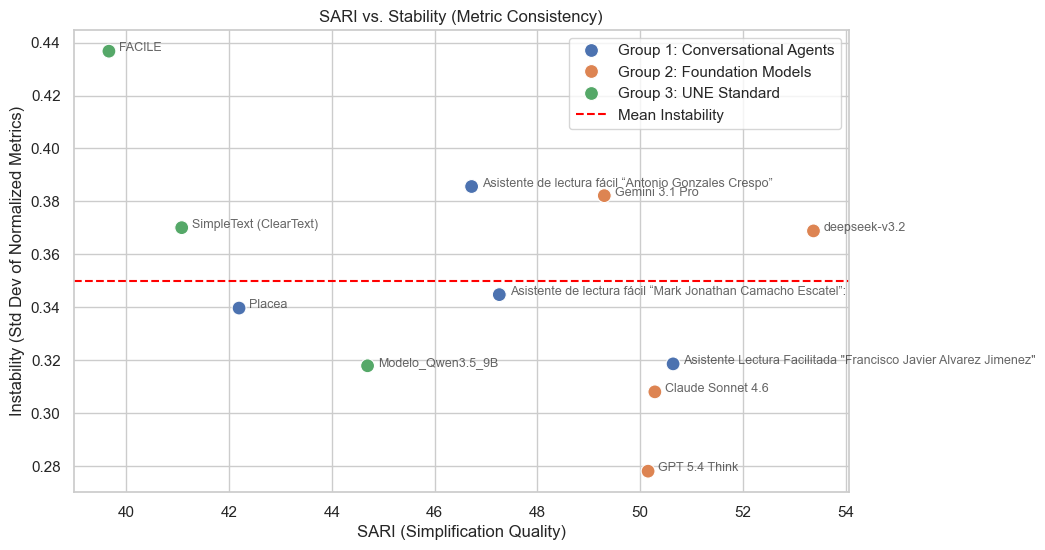

Pearson correlation between SARI and Instability: -0.47


In [92]:
# Normalización de métricas
df_m = df[['document_id'] + metricas].set_index('document_id')
df_norm = (df_m - df_m.min()) / (df_m.max() - df_m.min())

# Calcular Estabilidad (desviación estándar de métricas normalizadas)
# Menor desviación = Mayor estabilidad/equilibrio entre métricas
df['stability_std'] = df_norm.std(axis=1).values
df['norm_mean'] = df_norm.mean(axis=1).values

# Mostrar tabla de estabilidad
print("Tools ranked by Stability (Lower Std Dev = More Stable)")
display(df[['document_id', SummaryColumn.ORIG_SARI, 'stability_std', 'norm_mean']].sort_values(by='stability_std'))

# Gráfica de dispersión: SARI vs Estabilidad
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=SummaryColumn.ORIG_SARI, y='stability_std', hue='Grupo', s=100)
for i in range(df.shape[0]):
    plt.text(df[SummaryColumn.ORIG_SARI].iloc[i]+0.2, df.stability_std.iloc[i], df.document_id.iloc[i], fontsize=9, alpha=0.7)

plt.title('SARI vs. Stability (Metric Consistency)')
plt.xlabel('SARI (Simplification Quality)')
plt.ylabel('Instability (Std Dev of Normalized Metrics)')
plt.axhline(df['stability_std'].mean(), color='red', linestyle='--', label='Mean Instability')
plt.legend()
plt.show()

# Correlación de Pearson
corr = df[[SummaryColumn.ORIG_SARI, 'stability_std']].corr().iloc[0,1]
print(f"Pearson correlation between SARI and Instability: {corr:.2f}")


## Store all data of the metrics calculate

In [93]:
df.to_excel('analisis_herramientas_completo.xlsx', index=False)

# Get Metrics of Gold Reference

In [94]:
df_golf = pd.read_excel("comparacion.xlsx", sheet_name='Matriz comparativa')

In [ ]:
ORIGINAL_FORM = ""
REFERENCE_FORM = ""

for row in df_golf.itertuples():
    if row[2] == "TEXTO ADAPTADO (SALIDA DE CADA HERRAMIENTA DE LF)":
        ORIGINAL_FORM = clean_text(row[3])
        REFERENCE_FORM = clean_text(row[4])

print("Original Text:", ORIGINAL_FORM[:150])
print("="*50)
print("Reference Text:", REFERENCE_FORM[:150])

Original Text: AUTORIZACIÓN DE DIFUSIÓN DE IMAGEN/VÍDEO D./Dña. con DNI / Pasaporte nº y con email (a efectos de tratamiento de los datos): , autoriza a la Universid
Reference Text: Permiso para usar mis fotos o vídeos Datos personales Nombre y apellidos: Número de Documento Nacional de Identidad o pasaporte: Correo electrónico: D


: 

In [ ]:
cal = MerTrans()
bleu=cal.get_bleu_metric([ORIGINAL_FORM], [REFERENCE_FORM])
bertscore=cal.get_bert_score([ORIGINAL_FORM], [REFERENCE_FORM])
meaning_bert=cal.get_meaning_bert_score([ORIGINAL_FORM], [REFERENCE_FORM])
roberta_sense_facil=cal.get_roberta_sense_facil_metric([ORIGINAL_FORM], [REFERENCE_FORM])

In [ ]:
metrics_min =df[[
    SummaryColumn.ORIG_BLEU, 
    SummaryColumn.ORIG_BERTSCORE_F1, 
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING
    ]].min()

metrics_max = df[[
    SummaryColumn.ORIG_BLEU, 
    SummaryColumn.ORIG_BERTSCORE_F1, 
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING
    ]].max()

metrics_mean = df[[
    SummaryColumn.ORIG_BLEU, 
    SummaryColumn.ORIG_BERTSCORE_F1, 
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING
    ]].mean()

In [ ]:
df_metrics_gold_summary = pd.DataFrame(
    {
        "Metric": ["BLEU", "BERTScore F1", "Meaning BERT", "Roberta Sense Facil"],
        "Value": [bleu.bleu, bertscore.mean_f1, meaning_bert.mean_score, roberta_sense_facil.preserves_meaning],
        "Min": [metrics_min[SummaryColumn.ORIG_BLEU], metrics_min[SummaryColumn.ORIG_BERTSCORE_F1], metrics_min[SummaryColumn.ORIG_MEANING_BERT], metrics_min[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING]],
        "Max": [metrics_max[SummaryColumn.ORIG_BLEU], metrics_max[SummaryColumn.ORIG_BERTSCORE_F1], metrics_max[SummaryColumn.ORIG_MEANING_BERT], metrics_max[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING]],
        "Mean": [metrics_mean[SummaryColumn.ORIG_BLEU], metrics_mean[SummaryColumn.ORIG_BERTSCORE_F1], metrics_mean[SummaryColumn.ORIG_MEANING_BERT], metrics_mean[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING]]
    }

)

In [ ]:
df_metrics_gold_summary

In [ ]:
print(bleu.bleu)
print(bertscore.mean_f1)
print(meaning_bert.mean_score)
print(roberta_sense_facil.preserves_meaning)

In [ ]:
bertscore

In [ ]:
df[df[SummaryColumn.ORIG_BLEU] >= bleu.bleu][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_BLEU, ascending=False)

In [ ]:
df[df[SummaryColumn.ORIG_BERTSCORE_F1] >= bertscore.mean_f1][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_BERTSCORE_F1, ascending=False)

In [ ]:
df[df[SummaryColumn.ORIG_MEANING_BERT] >= meaning_bert.mean_score][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_MEANING_BERT, ascending=False)

In [ ]:
df[df[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING] >= roberta_sense_facil.preserves_meaning][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING, ascending=False)